# 01 - Exploratory Data Analysis

Objective:
Understand the characteristics of the Delhi Urban Heat Dataset generated during Phase 1 and identify relationships between land surface temperature and environmental predictors.

### Import Required Libraries

The following libraries are used for data manipulation and visualization during exploratory analysis.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)

### Load the Processed Dataset

The dataset contains grid-level thermal and environmental indicators generated during Phase 1.

In [3]:
df = pd.read_csv("../data/processed/delhi_heat_dataset_v1.csv")

### Inspect Dataset Structure

Examine the dimensions, sample records, and data types of the exported dataset.

In [4]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (31932, 5)


,system:index,mean_lst,mean_ndbi,mean_ndvi,.geo
0,"3,435,913,202",22.599892,-0.045069,0.188354,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
1,"3,436,013,202",17.924864,-0.016179,0.129377,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
2,"3,436,113,202",25.920861,-0.021533,0.149206,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
3,"3,436,213,202",37.349696,-0.046880,0.184968,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."
4,"3,435,813,203",31.636029,-0.028314,0.119132,"{""geodesic"":false,""crs"":{""type"":""name"",""proper..."


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31932 entries, 0 to 31931
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  31932 non-null  str    
 1   mean_lst      31932 non-null  float64
 2   mean_ndbi     31932 non-null  float64
 3   mean_ndvi     31932 non-null  float64
 4   .geo          31932 non-null  str    
dtypes: float64(3), str(2)
memory usage: 1.2 MB


In [7]:
df.columns.tolist()

['system:index', 'mean_lst', 'mean_ndbi', 'mean_ndvi', '.geo']

In [12]:
df = df.drop(columns=['system:index', '.geo'])

print("Remaining columns:")
print(df.columns.tolist())

Remaining columns:
['mean_lst', 'mean_ndbi', 'mean_ndvi']


### Check for Missing Values

Missing observations can influence model training and evaluation.

In [13]:
df.isnull().sum()

mean_lst     0
mean_ndbi    0
mean_ndvi    0
dtype: int64

### Summary Statistics

Compute descriptive statistics to understand the range and variability of the variables.

In [14]:
df.describe()

,mean_lst,mean_ndbi,mean_ndvi
count,31932.000000,31932.000000,31932.000000
mean,42.660518,-0.048002,0.172486
std,4.928169,0.044906,0.062553
min,15.006653,-0.238950,0.009721
25%,40.179872,-0.079954,0.124822
50%,42.761849,-0.044410,0.167220
75%,45.545346,-0.013512,0.216593
max,57.646485,0.125919,0.378341


### Distribution of Variables

Visualize the distributions of land surface temperature, vegetation intensity, and built-up intensity.

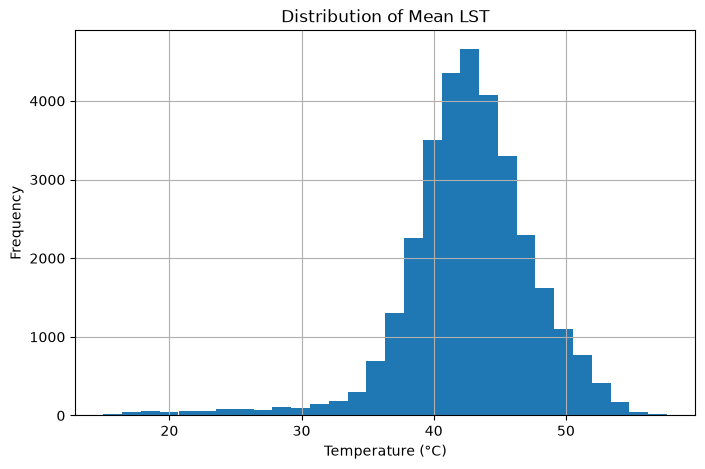

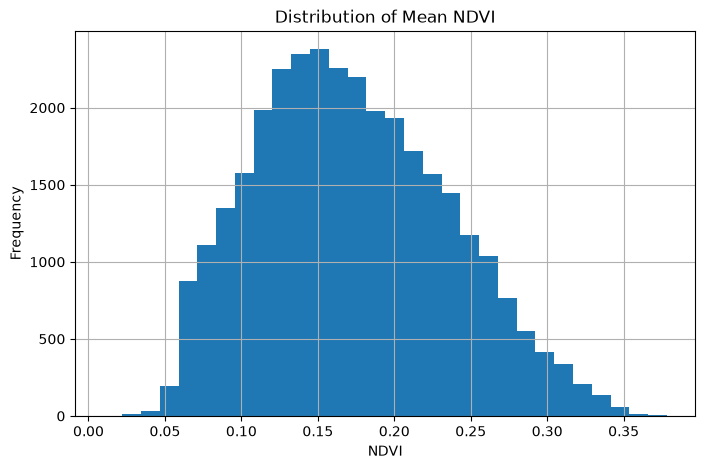

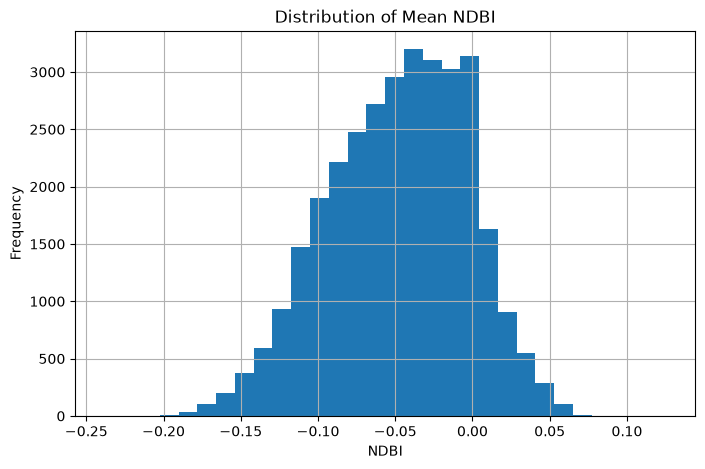

In [18]:
df['mean_lst'].hist(bins=30)
plt.title('Distribution of Mean LST')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.show()

df['mean_ndvi'].hist(bins=30)
plt.title('Distribution of Mean NDVI')
plt.xlabel('NDVI')
plt.ylabel('Frequency')
plt.show()

df['mean_ndbi'].hist(bins=30)
plt.title('Distribution of Mean NDBI')
plt.xlabel('NDBI')
plt.ylabel('Frequency')
plt.show()

### Correlation Between Variables

Evaluate linear relationships between thermal and environmental indicators.

In [17]:
df[['mean_lst', 'mean_ndvi', 'mean_ndbi']].corr()

,mean_lst,mean_ndvi,mean_ndbi
mean_lst,1.000000,-0.371303,0.588498
mean_ndvi,-0.371303,1.000000,-0.863546
mean_ndbi,0.588498,-0.863546,1.000000


In [ ]:
corr = df.corr()

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Matrix')
plt.show()

## Key Findings

- The dataset contains 31,932 grid-level observations.
- No missing values were detected across the exported variables.
- Land Surface Temperature (LST) exhibits a near-normal distribution centered around approximately 42–43°C.
- NDVI shows a moderate negative correlation with LST (r ≈ -0.37), suggesting that vegetated areas tend to experience lower surface temperatures.
- NDBI demonstrates a moderate positive correlation with LST (r ≈ 0.59), indicating that built-up intensity is associated with elevated temperatures.
- NDVI and NDBI are strongly negatively correlated (r ≈ -0.86), reflecting the inverse relationship between vegetation cover and urban development.